In [1]:
%matplotlib inline
import os
import numpy as np
import matplotlib.pyplot as plt
from astropy.io import fits
from astropy.table import Table

from astropy import units as u
from astropy import stats


import matplotlib as mpl
label_size = 8
mpl.rcParams['xtick.labelsize'] = 14
mpl.rcParams['ytick.labelsize'] = 14

## Data preparation

In [12]:
def schechter(s, a=0, S0=1, N0=1):
    
    return N0*3600/S0*(s/S0)**(a+1)*np.exp(-s/S0)

In [3]:
from scipy import interpolate

def flux_scaling(wavelength, target_wavelength, flux=1, SED_template='data/uds_composite_sed_Lir_ld.dat', z=2.0,
                 debug=False):
    """interpolate the flux at a specified wavelength
    
    Params:
        wavelength : in um
        flux : any units, self consistent
    """
    SED = np.loadtxt(SED_template)
    f_SED = interpolate.interp1d(SED[:,0]*(1.0+z), SED[:,1]/(1+z)**4)
    scale_factor = flux / f_SED(wavelength)
    if debug:
        print("flux at {}: {}".format(wavelength, f_SED(wavelength)))
        print("flux at {}: {}".format(target_wavelength, f_SED(target_wavelength)))
        print("scale_factor: {}".format(scale_factor))
        print("flux difference: {}".format(f_SED(wavelength)/f_SED(target_wavelength)))
    return scale_factor * f_SED(target_wavelength)

S_alma_scale = {}
S_alma = {'B3': 3027.9403678720932, 'B4': 2085.4643523587724, 'B5': 1595.2429758332012, 'B6': 1259.8894674554122, 
          'B7': 886.746475901551, 'B8': 673.4616464220171, 'B9': 444.86026069217337, 'B10': 341.799906987015}
S_ref = {'B3': 3000., 'B4': 2000., 'B5': 1500., 'B6': 1200., 'B7': 870., 'B8': 650., 'B9': 440., 'B10': 340.}
for band in ['B3','B4','B5','B6','B7','B8','B9','B10']:
    S_alma_scale[band] = flux_scaling(S_alma[band], S_ref[band], z=2.0)
print(S_alma_scale)

{'B3': 1.0382580304780473, 'B4': 1.1999533136892222, 'B5': 1.2966567022995046, 'B6': 1.2177778304099698, 'B7': 1.0733908077711678, 'B8': 1.1238182849239595, 'B9': 1.0292754797521029, 'B10': 1.0000000000000004}


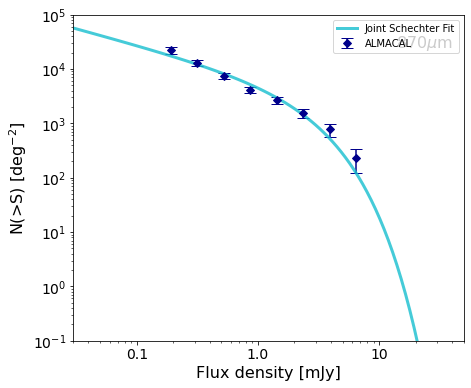

In [4]:
# plot the number counts of ALMA band 7 / 850mm

model_dir = 'data/'
S850_to_S870 = 0.92
S_almacal_B7toS870 = 1.07

fig = plt.figure(figsize=(7,6))
ax = fig.add_subplot(111)
ax.set_xscale("log")
ax.set_yscale("log")
ax.xaxis.set_tick_params(labelsize=14)
ax.yaxis.set_tick_params(labelsize=14)

# initialize the data used for fitting
B7_flux = []
B7_N = []
B7_Nerr_lower = []
B7_Nerr_upper = []

if False:
    Model_Popping = Table.read('./data/ModelsPopping/number_counts_Jianhang.dat', format='ascii')
    Model_Popping_dN = Table.read('./data/ModelsPopping/number_counts_Jianhang_differential.dat', format='ascii')
#     ax.plot(Model_Popping['flux']*0.92, Model_Popping['N850'], color='dimgray', ls='--', label='Popping et al. (2020)')

if True:
    # show the theoretical models of Lagos
    Lagos_model_dir = os.path.join(model_dir, 'ModelsLagos2')
    Lagos_B7 = np.loadtxt(os.path.join(Lagos_model_dir,'ALMA_Band7.txt'))
#     ax.plot(10**Lagos_B7[:,0], Lagos_B7[:,1], color='tab:red', ls='-.',  label='Lagos et al. (2020)')
    # show lagos+Eagle prediction
    Lagos_eagle = np.loadtxt('data/ModelsLagos2/NumberCountsALMA_EAGLE_cumulative.dat')
    #ax.plot(10**Lagos_eagle[:,0], Lagos_eagle[:,2], color='tab:blue', ls='-.', label='Lagos+EAGLE+Band7')
#     ax.plot(10**Lagos_eagle[:,0], Lagos_eagle[:,4], color='tab:blue', ls='-.', label='EAGLE')

    
if True:
    # Theoretical models of Bethermin
    Bethermin_model = Table.read('data/ModelsBethermin/SIDES_counts_870.txt', format='ascii')
    Bethermin_flux = Bethermin_model['col1']
    Bethermin_dN = Bethermin_model['col2']/(Bethermin_flux**2.5)*(np.pi/180)**2
    Bethermin_NN = []
    for i in range(0,len(Bethermin_dN)):
        Bethermin_NN.append(np.sum(Bethermin_dN[i:-2]*np.diff(Bethermin_flux[i:-1])))
#     ax.plot(Bethermin_flux*1000, Bethermin_NN, color='darkblue', ls=':', label='Bethermin et al. (2017)')    
    
    
if False:
    # plot Geach 2017
    S_Geach = [3.5,4.5,5.5,6.5,7.5,8.5,9.5,10.5,11.5,12.5,13.5,14.5,15.5]
    N_Geach = [1012.3, 508.0, 271.9, 151.8, 85.3, 47.1, 26.4, 14.5, 8.7, 5.5, 3.2, 2.4, 1.8]
    Nerr_poisson = [19.6, 9.7,6.5,4.3,3.1,2.3,1.6,1.2,0.8,0.6,0.5,0.3,0.2]
    Nerr_lower_Geach = np.sqrt(np.array([19.2, 12.0, 8.2, 6.0, 4.4, 3.3, 2.5, 1.9, 1.5, 1.2, 0.9, 0.8, 0.7])**2 + np.array(Nerr_poisson)**2)
    Nerr_upper_Geach = np.sqrt(np.array([19.6, 12.3, 8.5, 6.2, 4.7, 3.6, 2.8, 2.2, 1.8, 1.5, 1.2, 1.1, 1.0])**2 + np.array(Nerr_poisson)**2)
#     ax.errorbar(np.array(S_Geach)*S850_to_S870, N_Geach, yerr=[Nerr_lower_Geach, Nerr_upper_Geach], 
#             markersize=6, marker='X', capsize=6.0, linestyle="none", color='tab:green', alpha=0.6,
#             label='Geach et al. (2017), single-dish')

if True: # Lovell+2021
    #Simba_flux = np.array([1.12, 1.41, 1.78, 2.24, 2.82, 3.55, 4.47, 5.62, 7.08, 8.91, 11.22, 14.13, 17.78, 22.39])
    #Simba_N = np.array([1502.45, 1074.74, 761.00, 506.74, 308.15, 170.04, 83.87, 37.09, 14.85, 5.85, 2.39, 0.24, 0,0])
    #line_simba, = ax.plot(Simba_flux, Simba_N, color='blue', ls='-', alpha=0.6, label='Lovell et al. (2021) SIMBA')
    #Simba
    Simba_simu = np.loadtxt('./data/simba_differential_number_counts.txt')
    Simba_flux = 10**Simba_simu[:,0]
    Simba_dN = Simba_simu[:,1]
    Simba_flux_loginterv = 0.1
    Simba_flux_up = 10**(np.log10(Simba_flux) - Simba_flux_loginterv/2.0)
    Simba_flux_down = 10**(np.log10(Simba_flux) + Simba_flux_loginterv/2.0)
    Simba_dN_new = Simba_dN*Simba_flux_loginterv / (Simba_flux_down - Simba_flux_up)
    Simba_N = np.cumsum((0.5*(Simba_dN_new[1:] + Simba_dN_new[:-1]) * np.diff(Simba_flux))[::-1])[::-1]
    #ax.plot(Simba_flux[:-1], Simba_N, color='tomato', ls='--', alpha=0.6,)# label='Lovell et al. (2021) SIMBA')
    Simba_select = Simba_flux[:-1]>0.8 # Simba only complete for S870>1mJy, 0.8 to make the break visible in the plot
#     line_simba, = ax.plot(Simba_flux[:-1][Simba_select], Simba_N[Simba_select], color='tomato', ls='-', alpha=0.8, label='Lovell et al. (2021)')
    
    # show the EAGLE prediction
    Eagle_flux_loginterv = 0.1
    Eagle_simu = np.loadtxt('./data/eagle_differential_counts_sfr_0.1.dat')
    Eagle_flux = Eagle_simu[:,0]
    Eagle_flux_up = 10**(np.log10(Eagle_flux) - Eagle_flux_loginterv/2.0)
    Eagle_flux_down = 10**(np.log10(Eagle_flux) + Eagle_flux_loginterv/2.0)
    Eagle_dN = Eagle_simu[:,1] * Eagle_flux_loginterv / (Eagle_flux_down - Eagle_flux_up)
    #line_eagle, = ax.plot(S850_to_S870*Eagle_flux, Eagle_dN, color='orange', ls='-', alpha=0.6, label='Lovell et al. (2021) EAGLE')
    Eagle_N = np.cumsum((0.5*(Eagle_dN[1:] + Eagle_dN[:-1]) * np.diff(Eagle_flux))[::-1])[::-1]
    #ax.plot(Eagle_flux[:-1], Eagle_N, color='blue', ls=(0,(3,1,1,1,1,1)), alpha=0.6, label='Lovell et al. (2021) EAGLE')
    #ax.plot(Eagle_flux[:-1], Eagle_N, color='darkorange', ls='-', alpha=0.6, label='McAlpine et al. (2019)')
    
if True:
    # plot Simpson+2020
    S_Simpson = [6.2, 6.9, 7.7, 8.6, 9.7, 10.8, 12.1, 13.5, 15.1, 16.8, 18.8]
    N_Simpson = [130, 85.9, 60.4, 40.9, 27.6, 20.1, 12.2, 6.1, 3.7, 1.8, 0.6]
    Nerr_upper_Simpson = [13, 9.5, 7.4, 5.8, 4.8, 4.1,3.3, 2.7, 2.3, 1.9, 1.4]
    Nerr_lower_Simpson = [12, 8.7, 6.7, 5.2, 4.2, 3.6, 2.6, 2.3, 1.5, 1.0, 0.5]
#     ax.errorbar(S_Simpson, N_Simpson, yerr=[Nerr_lower_Simpson, Nerr_upper_Simpson],
#                 label='Simpson et al. (2020)',
#                 markersize=6, marker='P', capsize=6.0, linestyle="none", color='slateblue', alpha=0.6)
    if True:
        B7_flux.append(S_Simpson)
        B7_N.append(N_Simpson)
        B7_Nerr_lower.append(Nerr_lower_Simpson)
        B7_Nerr_upper.append(Nerr_upper_Simpson)
    
if True:
    # The number counts from Bethermin+2020, ALPINE
    Bethermin_data = Table.read('data/datasets/Bethermin2020_ALPINE.txt', format='ascii')
#     ax.errorbar(Bethermin_data['S_cut'], Bethermin_data['NN_secure'], yerr=[Bethermin_data['NN_secure_err_lower'], Bethermin_data['NN_secure_err_upper']],
#                 label='Bethermin et al. (2020)',
#                 markersize=6, marker='o', capsize=6.0, linestyle="none", color='tab:pink', alpha=0.6)
    if True:
        B7_flux.append(Bethermin_data['S_cut'].tolist())
        B7_N.append(Bethermin_data['NN_secure'].tolist())
        B7_Nerr_lower.append(Bethermin_data['NN_secure_err_lower'].tolist())
        B7_Nerr_upper.append(Bethermin_data['NN_secure_err_upper'].tolist())

if True:
    # The results from Stach2018
    Stach2018_data = Table.read('data/datasets/Stach2018.txt', format='ascii')
    S_Stach2018 = Stach2018_data['S'].tolist()
    N_Stach2018 = Stach2018_data['N'].tolist()
    N_Stach2018_err_upper = Stach2018_data['N_err_upper'].tolist()
    N_Stach2018_err_lower = Stach2018_data['N_err_lower'].tolist()
#     ax.errorbar(S_Stach2018, N_Stach2018, yerr=[N_Stach2018_err_lower, N_Stach2018_err_upper], 
#                 markersize=7, marker='X', capsize=6.0, linestyle="none", color='coral', alpha=0.8,
#                 label='Stach et al. (2018)')
    if True:
        B7_flux.append(S_Stach2018)
        B7_N.append(N_Stach2018)
        B7_Nerr_lower.append(N_Stach2018_err_lower)
        B7_Nerr_upper.append(N_Stach2018_err_upper)
        
if True:
    # The results from Simpson2015
    S_Simpson2015 = [7.5, 9.0, 10.5, 12.]
    N_Simpson2015 = [51.6, 15.8, 5.8, 1.7]
    N_Simpson2015_err_lower = [12.4, 5.8, 3.1, 1.4]
    N_Simpson2015_err_upper = [15.8, 8.5, 5.6, 4.0]
#     ax.errorbar(S_Simpson2015, N_Simpson2015, yerr=[N_Simpson2015_err_lower, N_Simpson2015_err_upper], 
#                 markersize=6, marker='^', capsize=6.0, linestyle="none", color='tab:brown', alpha=0.6,
#                 label='Simpson et al. (2015)')
    if True:
        B7_flux.append(S_Simpson2015)
        B7_N.append(N_Simpson2015)
        B7_Nerr_lower.append(N_Simpson2015_err_lower)
        B7_Nerr_upper.append(N_Simpson2015_err_upper)

if True:
    # The results from Karim2013
    S_Karim2013 = [4.2, 5.2, 6.1, 7.1, 8.0, 9.0]
    N_Karim2013 = [167.3, 109.4, 75.2, 49.1, 25.9, 4.8]
    N_Karim2013_err = [28.6, 22.8, 18.8, 15.5, 12.5, 7.9]
#     ax.errorbar(S_Karim2013, N_Karim2013, yerr=N_Karim2013_err, 
#                 markersize=7, marker='*', capsize=6.0, linestyle="none", color='tab:orange', alpha=0.6,
#                 label='Karim et al. (2013)')
    if False:
        B7_flux.append(S_Karim2013)
        B7_N.append(N_Karim2013)
        B7_Nerr_lower.append(N_Karim2013_err)
        B7_Nerr_upper.append(N_Karim2013_err)
    
## The results comes from ALMACAL
if True:
    # Oteo Band 7
    S_Oteo2016 = [0.4, 1.0]
    N_Oteo2016 = [17e3, 3.8e3]
    N_Oteo2016_err_upper = [14.3e3, 3.2e3]
    N_Oteo2016_err_lower = [14.0e3, 3.1e3]
#     ax.errorbar(S_Oteo2016, N_Oteo2016, yerr=[N_Oteo2016_err_lower, N_Oteo2016_err_upper], 
#                 markersize=6, marker='>', capsize=6.0, linestyle="none", color='tab:red', alpha=0.6,
#                 label='(Oteo et al. 2016) ALMACAL ')
#     ax.errorbar(S_Oteo2016, N_Oteo2016, yerr=[N_Oteo2016_err_lower, N_Oteo2016_err_upper], 
#                 markersize=10, marker='>', capsize=6.0, linestyle="none", color='tab:red', alpha=0.6)
    if False:
        B7_flux.append(S_Oteo2016)
        B7_N.append(N_Oteo2016)
        B7_Nerr_lower.append(N_Oteo2016_err_lower)
        B7_Nerr_upper.append(N_Oteo2016_err_upper)
    

almacal_B7 = Table.read('data/B7_bus-False.txt', format='ascii')
#almacal_B7 = Table.read('tests/B7_number_counts_v5.1_py3.txt', format='ascii')
ax.errorbar(almacal_B7['flist']*S_almacal_B7toS870, almacal_B7['N'], yerr=almacal_B7['Nerr_lower'], label='ALMACAL',
            markersize=6, marker='D', capsize=6.0, linestyle="none", color='darkblue')

if True:
    B7_flux.append((almacal_B7['flist']*S_almacal_B7toS870).tolist())
    B7_N.append(almacal_B7['N'].tolist())
    B7_Nerr_lower.append(almacal_B7['Nerr_lower'])
    B7_Nerr_upper.append(almacal_B7['Nerr_upper'])



if True:
    B7_flux_fitted = np.logspace(-2, 1.5, 100)
    # plot the best fitting
    # scale_N0 = 3600/1000 # from Jy/arcmin2 to mJy/deg2
    # note that the values below are copied from the bestfitting. 
    # The alpha definite is a bit different here as the paper, see the schechter function in the beginning
    B7_schechter_sols = [-1.6,  2.2,  2.67] # [alpha-1, S0, N0]
    
    ax.plot(B7_flux_fitted, 
            schechter(B7_flux_fitted, *B7_schechter_sols), 
            linewidth=3., 
            alpha=0.8, 
            color='tab:cyan', 
            label='Joint Schechter Fit')

ax.set_xlabel('Flux density [mJy]', fontsize=16)
ax.set_ylabel('N(>S) [deg$^{-2}$]', fontsize=16)
#ax.set_title("870$\mu$ Number Counts", fontsize=16)
ax.text(.9,.9, '870$\mu$m', horizontalalignment='center', transform=ax.transAxes, fontsize=16)
ax.set_xticks([0.1, 1., 10.], [0.1, 1.0, 10])


ax.set_xlim(0.03, 50)
ax.set_ylim(0.1, 10**5)
ax.legend(fontsize=10)

#fig.savefig('./results/ALMACAL_band7.pdf', bbox_inches='tight')#, dpi=400)

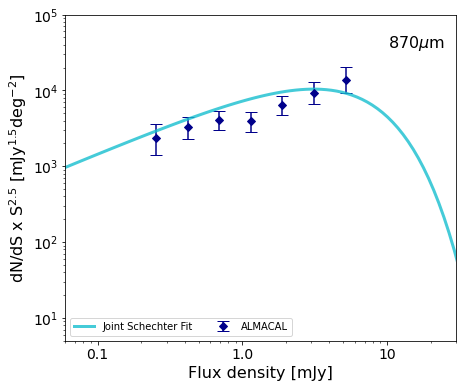

In [11]:
# plot the differential number counts of ALMA band 7 / 850mm
model_dir = 'data/'
S850_to_S870 = 0.92
S_almacal_to_S870 = 1.0/0.92

fig = plt.figure(figsize=(7,6))
ax = fig.add_subplot(111)
ax.set_xscale("log")
ax.set_yscale("log")
ax.xaxis.set_tick_params(labelsize=14)
ax.yaxis.set_tick_params(labelsize=14)
S850_to_S870 = 0.92

# initialize the data used for fitting
B7_dflux = []
B7_dN = []
B7_dNerr_lower = []
B7_dNerr_upper = []

# ALMACAL data points
# -------------------------------------------------------------------------------------------
if True:
    # Read ALMACAL number counts
    almacal_B7 = Table.read('data/B7_bus-False_diff.txt', format='ascii')
    
    yf = (almacal_B7['flist']*S_alma_scale['B7'])**2.5
    
    ax.errorbar(almacal_B7['flist']*S_alma_scale['B7'], 
                yf*almacal_B7['dN'], 
                yerr=[yf*almacal_B7['dNerr_lower'], 
                      yf*almacal_B7['dNerr_upper']], 
                label='ALMACAL', 
                markersize=6, 
                marker='D', 
                capsize=6.0, 
                linestyle="none", 
                color='darkblue')
    
    # Save the data to a df so I can access it later 
#     df_left = 
    
# -------------------------------------------------------------------------------------------    


if True:
    #plot the best fitting result
    B7_x_fitted = np.logspace(-2, 1.5, 100)
    yf = B7_x_fitted**2.5
    # scale_N0 = 3600/1000 # from Jy/arcmin2 to mJy/deg2
    # note that the values below are copied from the bestfitting. the alpha definite is a bit different here, see the schechter function in the beginning
    B7_schechter_diffsols = [-2.7, 3.9, 0.61] # [alpha-1, S0, N0], N0 here in mJy/arcmin2
    ax.plot(B7_x_fitted, 
            yf*schechter(B7_x_fitted, *B7_schechter_diffsols[:-1]), 
            color='tab:cyan', 
            linewidth=3, 
            alpha=0.8, 
            label='Joint Schechter Fit')

ax.set_xlabel('Flux density [mJy]', fontsize=16)
#ax.set_ylabel('dN/dS [mJy$^{-1}$deg$^{-2}$]', fontsize=16)
ax.set_ylabel('dN/dS x S$^{2.5}$ [mJy$^{1.5}$deg$^{-2}$]', fontsize=16)
#ax.set_title("870$\mu$m differential Number Counts", fontsize=16)
ax.text(.9,.9, '870$\mu$m', horizontalalignment='center', transform=ax.transAxes, fontsize=16)
ax.set_xticks([0.1, 1., 10.], [0.1, 1.0, 10])
    
ax.set_xlim(0.06, 30)
ax.set_ylim(5., 1e5)
ax.legend(fontsize=10, loc=3, ncol=2)

#fig.savefig('./results/ALMACAL_band7_differential.pdf', bbox_inches='tight')#, dpi=400)